In [3]:
print("hollow world")

hollow world


# 심화프로잭트: 다이캐스팅 공정 데이터 기반 품질 예측
다이캐스팅 설비에서 매 샷(Shot)마다 쌓이는 공정 변수(주조 온도, 압력, 속도 등) + 센서 데이터를 활용,\
불량 여부/유형을 자동 예측(분류)하는 머신러닝 모델을 만든다.


> 다이캐스팅이란?: 용융 금속을 금형에 고압으로 주입하여 정밀한 제품을 생산하는 공정

## 왜 필요한가?
다이캐스팅은 고압·고속으로 용융 금속을 금형에 주입하는 대량생산 공정이라 품질 관리가 중요하다.\
열가압실식(Hot Chamber)과 냉가압실식(Cold Chamber) 방식으로 구분되며, 합금 특성·주조 압력·제품 크기에 따라 방식을 선택한다.

현업에선 다음과 같은 문제가 발생한다.
1. 불량(미성형, 박리, 기공, 평탄, 개재물 등)이 나도 육안 검사 의존 → 판정 주관성/속도 한계로 생산성 저하
2. 불량 원인 추적이 어려워 공정 개선이 느림
3. 공정 데이터와 품질검사 결과를 잘 매핑 못해서 실시간 품질 관리가 약함

목표는 **데이터 기반으로 불량을 조기 감지하고 재발 방지**가 핵심이다.

## 실행 목표
1. 공정 변수 + 센서 데이터로 불량 여부 판별
2. 불량 유형과 공정 변수의 관계 분석 + 분류 모델 구축
3. 불량의 주요 원인 변수를 찾아 인사이트 도출 (공정 최적화)
4. 실시간 품질 예측 체계

## 데이터 구성 파악
1. 공정(Process) 데이터
    - Shot ID, Injection Speed, Die Temperature, Casting Pressure, Cooling Time 등
    
2. 센서(Sensor) 데이터 예시
    - Mold Temp Sensor, Hydraulic Pressure, Vibration Sensor, Flow Rate Sensor 등

3. 품질/불량(Defects)
    - Defect Type(불량 유형), Defect Status(양품/불량)

## 분석필수 요소
1. EDA(탐색적 분석)
    - 공정 변수와 불량의 관계, 센서 이상치 탐색/처리, 불량 유형별 비교
2. 통계 검정(근거 만들기)
    - 불량 유형별 공정 변수 차이 검증에 t-검정/ANOVA 활용
3. 분류 모델링 + 평가 + 해석
    - RandomForest / XGBoost / LightGBM 등으로 분류 모델 비교·선정 ?
    - 평가지표는 Precision / Recall / F1 중심
    - Feature Importance + SHAP으로 왜 그런 예측이 나왔는지 해석

## 최종 산출물
- EDA 시각화: 박스플롯, 상관행렬, 이상치 탐색 등
- 모델 결과: 불량 유형 분류, 성능 평가(Precision/Recall/F1)
- 주요 원인 변수 도출 및 공정 최적화 인사이트

## 데이터 전처리(1차) 및 EDA

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


In [5]:
df = pd.read_csv("DieCasting_Quality_Raw_Data.csv", header=[0,1])
df.head()

Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                        ...     Defects  \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   ... Blow_Hole_2   
0               214           0.008                 10  ...           0   
1               217           0.008                 11  ...           0   
2               214           0.008                 11  ...           0   
3               217           0.008                 11  ...           0   
4               217           0.008                 12  ...           0   

                                                                             \
  Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2 Scratch_2   
0       0      0             0               0          0       0         0   
1       0      0             0               0          0       0         0   
2       0      0             0               0          0       0         0   
3       0      0             0               0          0       0         0   
4       0      0             0               0          0       0         0   

                              
  Buring_Mark_2 Inclusions_2  
0             0            0  
1             0            0  
2             0            0  
3             0            0  
4             0            0  

[5 rows x 57 columns]

In [6]:
# =========================
# 1) 파일 구성 먼저 확인
# =========================
print("===== 기본 정보 =====")
print(f"Shape: {df.shape}")
# 컬럼 상위 인덱스 확인
top_groups = (
    df.columns                 # 컬럼 인덱스(Index/MultiIndex)
      .get_level_values(0)     # 0레벨(최상위) 값들만 추출
      .unique()                # 중복 제거(등장 순서 유지)
      .tolist()                # list로 변환
)
print("상위 그룹 컬럼 개수:", top_groups)
print(df.columns.get_level_values(0).value_counts())

===== 기본 정보 =====
Shape: (7535, 57)
상위 그룹 컬럼 개수: ['Process', 'Sensor', 'Defects']
Defects    26
Process    17
Sensor     14
Name: count, dtype: int64


In [7]:
# =========================
# 2) 메인 데이터 컬럼 구조 확인 (Process / Sensor / Defects)
# =========================
print("===== 2) 그룹별 컬럼 구조 확인 =====")

# MultiIndex 컬럼의 0레벨(최상위)의 컬럼들만 잘라서 가져옴
process_df = df.xs("Process", axis=1, level=0)
sensor_df  = df.xs("Sensor",  axis=1, level=0)
defects_df = df.xs("Defects", axis=1, level=0)

process_df.columns = process_df.columns.astype(str).str.strip()
sensor_df.columns  = sensor_df.columns.astype(str).str.strip()
defects_df.columns = defects_df.columns.astype(str).str.strip()

print("Process 컬럼명(전체):")
print(process_df.columns.tolist())
print()

print("그룹별 dtype 분포(Process):")
print(process_df.dtypes.value_counts())
print()
print("="*60)

print("\nSensor 컬럼명(전체):")
print(sensor_df.columns.tolist())
print()

print("그룹별 dtype 분포(Sensor):")
print(sensor_df.dtypes.value_counts())
print()
print("="*60)

print("\nDefects 컬럼명(전체):")
print(defects_df.columns.tolist())
print()

print("그룹별 dtype 분포(Defects):")
print(defects_df.dtypes.value_counts())

===== 2) 그룹별 컬럼 구조 확인 =====
Process 컬럼명(전체):
['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time']

그룹별 dtype 분포(Process):
float64    10
int64       7
Name: count, dtype: int64


Sensor 컬럼명(전체):
['Melting_Furnace_Temp', 'Air_Pressure', 'Air_Pressure_Min', 'Air_Pressure_Max', 'Coolant_Temp', 'Coolant_Temp_Min', 'Coolant_Temp_Max', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Temp_Min', 'Factory_Temp_Max', 'Factory_Humidity', 'Factory_Humidity_Min', 'Factory_Humidity_Max']

그룹별 dtype 분포(Sensor):
float64    10
int64       4
Name: count, dtype: int64


Defects 컬럼명(전체):
['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1', 'Dent_1', 'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1', 'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2', 'Bubbl

In [8]:
# =========================
# 3) 타겟(y=defect) 구조 확인
# =========================
print("===== 3) 타겟(y=defect) 구조 확인 =====")

# 샷별 불량 개수(26개 defect 컬럼의 합)
defect_count = defects_df.sum(axis=1)

# (B) 이진 타겟(불량 하나라도 있으면 1)
y_any_defect = (defect_count > 0).astype(int)

print("샷별 불량 개수 요약:")
print(defect_count.describe())
print()

print("양품(0) / 불량(1) 개수:")
print(y_any_defect.value_counts().rename("count"))
print()

print("양품(0) / 불량(1) 비율:")
print(y_any_defect.value_counts(normalize=True).rename("ratio"))
print()

print("한 샷에서 동시에 발생한 불량 개수 분포(상위):")
print(defect_count.value_counts().head(10))
print()

print("불량 컬럼별 발생 횟수 TOP 10:")
print(defects_df.sum().sort_values(ascending=False).head(10))
print()

===== 3) 타겟(y=defect) 구조 확인 =====
샷별 불량 개수 요약:
count    7535.000000
mean        0.254015
std         0.504534
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.000000
dtype: float64

양품(0) / 불량(1) 개수:
0    5846
1    1689
Name: count, dtype: int64

양품(0) / 불량(1) 비율:
0    0.775846
1    0.224154
Name: ratio, dtype: float64

한 샷에서 동시에 발생한 불량 개수 분포(상위):
0    5846
1    1484
2     185
3      20
Name: count, dtype: int64

불량 컬럼별 발생 횟수 TOP 10:
Short_Shot_1     512
Blow_Hole_1      245
Stain_1          209
Short_Shot_2     182
Exfoliation_1    175
Blow_Hole_2      161
Exfoliation_2    134
Deformation_1    109
Bubble_1          72
Deformation_2     65
dtype: int64



In [9]:
# =========================
# 4) 결측치(NA) 구조 확인
# =========================
print("===== 4) 결측치(NA) 확인 =====")

na_count = df.isna().sum().sort_values(ascending=False)
na_cols = na_count[na_count > 0]

print("그룹별 결측치 합(총 결측 수):")
print(pd.Series({
    "Process": process_df.isna().sum().sum(),
    "Sensor":  sensor_df.isna().sum().sum(),
    "Defects": defects_df.isna().sum().sum()
}))
print()

print("결측치가 있는 컬럼만(개수):")
print(na_cols)
print()


===== 4) 결측치(NA) 확인 =====
그룹별 결측치 합(총 결측 수):
Process      0
Sensor     540
Defects      0
dtype: int64

결측치가 있는 컬럼만(개수):
Sensor  Factory_Temp            90
        Factory_Humidity        90
        Factory_Temp_Max        90
        Factory_Humidity_Max    90
        Factory_Humidity_Min    90
        Factory_Temp_Min        90
dtype: int64



In [10]:
# =========================
# 5) 중복 확인
# =========================
process_df = df.xs("Process", axis=1, level=0)
process_df.columns = process_df.columns.astype(str).str.strip() 

# 키 후보 찾기: 식별자
print("id 중복 개수:", process_df["id"].duplicated().sum())
print("(Product_Type, Shot) 중복 개수:",process_df[["Product_Type", "Shot"]].duplicated().sum())
print("전체 행 완전 중복 개수:", df.duplicated().sum())

print("어떤 (Product_Type, Shot)이 많이 반복되는가:")
print(process_df[["Product_Type", "Shot"]].value_counts().head(10))

id 중복 개수: 0
(Product_Type, Shot) 중복 개수: 5532
전체 행 완전 중복 개수: 0
어떤 (Product_Type, Shot)이 많이 반복되는가:
Product_Type  Shot
2             45      7
              44      7
              46      7
              47      7
1             12      5
              11      5
              10      5
              6       5
2             599     5
              394     5
Name: count, dtype: int64


## 전처리/분석 과정 요약
1. 파일 구성\
DieCasting_Quality_Raw_Data.csv는 (7535, 57)
상위그룹\
Process 17개\
Sensor 14개\
Defects 26개

2. 그룹별 컬럼 구조 확인\
Process: 숫자형( int64 7개 + float64 10개 )\
이름중에 공백이 섞여있기 때문에 이후 전처리에 수정 (수정완)\
Sensor: int64 4개 + float64 10개\
Defects: 26개 전부 int64(0/1 플래그)

3. 타겟(y=defect) 구조 확인\
Defects 26개를 합친 샷별 불량 개수를 만듦\
불량 하나라도 있으면 1인 이진값으로 만든 타겟컬럼(y_any_defect) 생성\
양품(0): 77.6% (5846개)\
불량(1): 22.4% (1689개)\
한 샷에서 불량은 최대 3개까지 동시 발생한다.\
가장 많이 발생한 불량은\
Short_Shot_1(512), Blow_Hole_1(245), Stain_1(209) 등

4. 결측치 확인\
결측은 Sensor에서만 있고 총 540개, 특정 6개 컬럼에만 각각 90개씩 결측값을 가짐\
Factory_Temp, Factory_Humidity, Factory_Temp_Min/Max, Factory_Humidity_Min/Max\
결측 처리는 일부 센서 6개에 대해서만 진행

5. 중복 확인\
id는 중복 0 → id는 유니크 키로 사용 가능\
전체 행 완전 중복 0 → 데이터 복제 문제는 없을것으로 예상\
단, 특정 (Product_Type, Shot)이 5~7번씩 반복 등장하는것으로 확인


---
## 6 컬럼 구조 확인

#### Process 컬럼 (17개)
- 다이캐스팅 공정에서 설정한 조건(속도·압력·시간·형체력 등)을 모아둔 변수
1. id: 각 샷(레코드)을 구분하는 고유 번호
2. Product_Type: 제품/금형/품번 타입을 나타내는 코드(범주형일 가능성 큼)
3. Shot: 생산 순서(샷 번호)
4. Velocity_1: 사출 속도 1단(초기 구간 속도)
5. Velocity_2: 사출 속도 2단(중간 구간 속도)
6. Velocity_3: 사출 속도 3단(후반 구간 속도)
7. High_Velocity: 사출 과정에서의 최고 속도(피크)
8. Cylinder_Pressure: 사출 실린더 압력
9. Rapid_Rise_Time: 속도/압력이 급격히 올라가는 구간의 시간
10. Biscuit_Thickness: 샷 슬리브에 남는 비스킷(잔류 금속) 두께
11. Clamping_Force: 금형을 잡아주는 형체력(누설/플래시와 관련될 수 있음)
12. Cycle_Time: 한 샷을 찍는 전체 사이클 시간
13. Pressure_Rise_Time: 압력이 목표치로 올라가는 데 걸린 시간
14. Casting_Pressure: 충전/가압 단계의 주조 압력
15. spray_Time: 전체 스프레이(이형제 분사 등) 시간
16. Spray_1_Time: 스프레이 1단 구간 시간
17. Spray_2_Time: 스프레이 2단 구간 시간


#### Sensor 컬럼(14)
- 설비/환경이 실제로 측정한 상태값(온도·압력·습도 등)을 모아둔 센서 변수
1. Melting_Furnace_Temp: 용해로(용탕) 온도
2. Air_Pressure: 공압(에어) 라인 압력
3. Air_Pressure_Min: 해당 구간에서 기록된 에어 압력 최소값
4. Air_Pressure_Max: 해당 구간에서 기록된 에어 압력 최대값
5. Coolant_Temp: 냉각수 온도
6. Coolant_Temp_Min: 냉각수 온도 최소값
7. Coolant_Temp_Max: 냉각수 온도 최대값
8. Coolant_Pressure: 냉각수 압력
9. Factory_Temp: 공장(주변 환경) 온도
10. Factory_Temp_Min: 공장 온도 최소값
11. Factory_Temp_Max: 공장 온도 최대값
12. Factory_Humidity: 공장(주변 환경) 습도
13. Factory_Humidity_Min: 공장 습도 최소값
14. Factory_Humidity_Max: 공장 습도 최대값

#### Defects 컬럼 (26)
- 각 샷(생산)에서 검사로 확인된 불량 결과(종류별 발생 여부/개수/점수)를 모아둔 타겟(라벨) 변수
- 13종의 불량 분류
- _1/_2가 정확히 뭐지?: 
     - 각기다른 검사채널로 해석
        - 검사 위치/면(앞면·뒷면)
        - 캐비티(금형 2개 구멍: cavity 1, cavity 2)
        - 메라/검사 라인 2개(카메라1, 카메라2)
        - 등으로 해석함

1. Short_Shot_1: 미성형(충전 부족) 불량 채널1 값
2. Short_Shot_2: 미성형(충전 부족) 불량 채널2 값
3. Bubble_1: 기포 불량 채널1 값
4. Bubble_2: 기포 불량 채널2 값
5. Exfoliation_1: 박리(층 분리/벗겨짐) 불량 채널1 값
6. Exfoliation_2: 박리(층 분리/벗겨짐) 불량 채널2 값
7. Blow_Hole_1: 블로홀/기공 불량 채널1 값
8. Blow_Hole_2: 블로홀/기공 불량 채널2 값
9. Stain_1: 얼룩 불량 채널1 값
10. Stain_2: 얼룩 불량 채널2 값
11. Dent_1: 찍힘/눌림 불량 채널1 값
12. Dent_2: 찍힘/눌림 불량 채널2 값
13. Scratch_1: 스크래치 불량 채널1 값
14. Scratch_2: 스크래치 불량 채널2 값
15. Buring_Mark_1: 번마크/그을림 불량 채널1 값
16. Buring_Mark_2: 번마크/그을림 불량 채널2 값
17. Deformation_1: 변형 불량 채널1 값
18. Deformation_2: 변형 불량 채널2 값
19. Crack_1: 균열 불량 채널1 값
20. Crack_2: 균열 불량 채널2 값
21. Contamination_1: 오염(이물) 불량 채널1 값
22. Contamination_2: 오염(이물) 불량 채널2 값
23. Impurity_1: 불순물 불량 채널1 값
24. Impurity_2: 불순물 불량 채널2 값
25. Inclusions_1: 개재물(내부 이물) 불량 채널1 값
26. Inclusions_2: 개재물(내부 이물) 불량 채널2 값

---

## 이상치 확인

In [11]:
# =========================
# 6) 이상치(IQR) 확인
# =========================
import matplotlib.pyplot as plt


# 1) X, y 준비
X = pd.concat([process_df, sensor_df], axis=1).drop(columns=["id"])
y = y_any_defect

# 2) 결측치 처리: 중앙값으로 채우기(간단하게)->머신러닝 할땐 안쓸꺼임
X = X.fillna(X.median(numeric_only=True))

print("\n===== 전처리 결과 =====")
print("X shape:", X.shape)
print("y 분포:")
print(y.value_counts())
print("남은 결측치:", X.isna().sum().sum())
print()


===== 전처리 결과 =====
X shape: (7535, 30)
y 분포:
0    5846
1    1689
Name: count, dtype: int64
남은 결측치: 0



In [12]:
# 3) IQR 기반 이상치 마스크
q1 = X.quantile(0.25)
q3 = X.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr # lower 보다 작으면 이상치
upper = q3 + 1.5 * iqr # upper 보다 크면 이상치

# 이상치 마스크 만들기(True/False 표)
outlier_mask = X.lt(lower) | X.gt(upper) # True: 이상치, False: 정상
# X가 lower보다 작은지(less than) → True/False
# X가 upper보다 큰지(greater than) → True/False
# 둘 중 하나라도 True면 이상치(True)

# IQR=0인 컬럼은 이상치 판단이 의미 없을 수 있으니 제외
zero_iqr_cols = iqr.eq(0)
outlier_mask.loc[:, zero_iqr_cols] = False

# 4) 컬럼별 이상치 개수/비율
outlier_count_by_col = (
    outlier_mask
    .sum() # 이상치 총합
    .sort_values(ascending=False) # 이상치가 많은 컬럼부터 정렬
)
outlier_ratio_by_col = (outlier_count_by_col / len(X)).sort_values(ascending=False) # 비율화

print("===== 이상치 TOP 15: 개수 =====")
print(outlier_count_by_col.head(15))
print()

print("===== 이상치 TOP 15: 비율 =====")
print(outlier_ratio_by_col.head(15))
print()

rows_with_any_outlier = outlier_mask.any(axis=1).sum()
print("이상치가 1개라도 있는 행 수:", rows_with_any_outlier, "/", len(X))
print("비율:", rows_with_any_outlier / len(X))
print()

===== 이상치 TOP 15: 개수 =====
Factory_Temp          374
Velocity_2            184
Biscuit_Thickness      12
Cycle_Time             11
High_Velocity          10
Rapid_Rise_Time        10
Velocity_1              6
Pressure_Rise_Time      4
Velocity_3              4
Cylinder_Pressure       4
Product_Type            0
Clamping_Force          0
Casting_Pressure        0
Shot                    0
Spray_Time              0
dtype: int64

===== 이상치 TOP 15: 비율 =====
Factory_Temp          0.049635
Velocity_2            0.024419
Biscuit_Thickness     0.001593
Cycle_Time            0.001460
High_Velocity         0.001327
Rapid_Rise_Time       0.001327
Velocity_1            0.000796
Pressure_Rise_Time    0.000531
Velocity_3            0.000531
Cylinder_Pressure     0.000531
Product_Type          0.000000
Clamping_Force        0.000000
Casting_Pressure      0.000000
Shot                  0.000000
Spray_Time            0.000000
dtype: float64

이상치가 1개라도 있는 행 수: 590 / 7535
비율: 0.07830126078301261



<Figure size 1200x400 with 0 Axes>

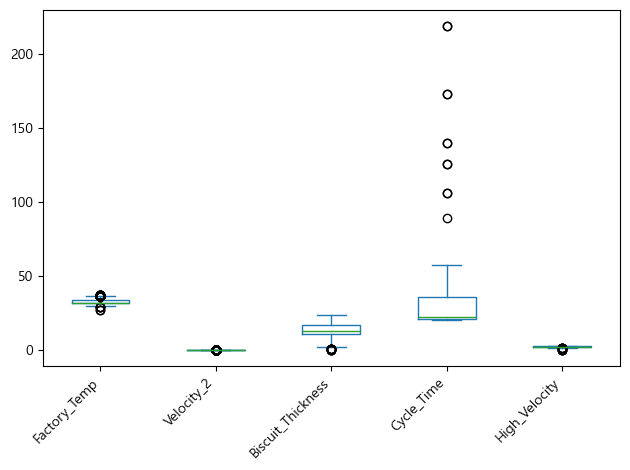

In [13]:
# 4) 시각화: 이상치 많은 컬럼 상위 6개 박스플롯
top_cols = outlier_count_by_col[outlier_count_by_col > 0].head(5).index

plt.figure(figsize=(12, 4))
X[top_cols].plot(kind="box")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
print("===== TOP 컬럼 min/max =====")
print(X[top_cols].agg(["min", "max"]))
print()

tmp = X[top_cols].copy()
tmp["y"] = y

print("===== 불량/양품 평균(mean) 비교 =====")
print(tmp.groupby("y")[top_cols].mean())
print()

print("===== 불량/양품 중앙값(median) 비교 =====")
print(tmp.groupby("y")[top_cols].median())
print()

===== TOP 컬럼 min/max =====
     Factory_Temp  Velocity_2  Biscuit_Thickness  Cycle_Time  High_Velocity
min          27.4       0.158                  0        20.2          0.000
max          37.0       0.212                 24       218.6          2.744

===== 불량/양품 평균(mean) 비교 =====
   Factory_Temp  Velocity_2  Biscuit_Thickness  Cycle_Time  High_Velocity
y                                                                        
0     32.809237    0.168863          14.140267   27.247725       2.308103
1     32.861575    0.168583          14.895796   29.425933       2.357656

===== 불량/양품 중앙값(median) 비교 =====
   Factory_Temp  Velocity_2  Biscuit_Thickness  Cycle_Time  High_Velocity
y                                                                        
0          32.1       0.168               13.0        22.5          2.157
1          32.1       0.168               16.0        35.0          2.506



## 사용 데이터 보고
데이터 크기: 7,535행\
타겟(y): Defects 26개 중 하나라도 1이면 불량(1), 아니면 양품(0)\
양품 5,846 (77.6%), 불량 1,689 (22.4%)

결측치: Sensor 일부(Factory 관련 6개)에 존재했으나, 이상치 확인 단계에서는 중앙값으로 임시 대체\
(추후 머신러닝 단계에서는 파이프라인으로 처리 예정)

## 이상치 보고
이상치 기준: IQR\
하한 = Q1 - 1.5×IQR\
상한 = Q3 + 1.5×IQR\
하한보다 작거나 상한보다 크면 이상치로 판단

1. 이상치가 1개라도 존재하는 행\
590 / 7,535 (약 7.83%)

2. 이상치가 많은 컬럼 TOP (개수 기준)
    1. Factory_Temp : 374개 (약 4.96%)
    2. Velocity_2 : 184개 (약 2.44%)
    3. Biscuit_Thickness : 12개
    4. Cycle_Time : 11개
    5. High_Velocity : 10개
    6. Rapid_Rise_Time : 10개
    7. 그 외 Velocity_1, Pressure_Rise_Time, Velocity_3, Cylinder_Pressure 등은 소수
    - 이상치는 Factory_Temp, Velocity_2에 상대적으로 많이 집중되어 있다.

3. 이상치 값 범위
    1. Factory_Temp: 27.4 ~ 37.0
    2. Velocity_2: 0.158 ~ 0.212
    3. Biscuit_Thickness: 0 ~ 24
    4. Cycle_Time: 20.2 ~ 218.6
    5. High_Velocity: 0.0 ~ 2.744
    - 0인 값들이 존재하기 때문에 측정 오류인지, 특정 상황인지 추후에 판단

4. 불량/양품 간 차이(참고: 평균·중앙값)
    - Cycle_Time, Biscuit_Thickness, High_Velocity는 불량(1)에서 더 큰 경향이 관찰된다
        - Biscuit_Thickness: 양품 13.0 → 불량 16.0
        - Cycle_Time: 양품 22.5 → 불량 35.0
        - High_Velocity: 양품 2.157 → 불량 2.506
    - 단순 이상치 보단 불량 신호일 가능성으로 볼수 있음

5. 판단
- IQR 기준 이상치는 행 기준 약 7.8% 수준, 특정 변수에 집중되어 있다.
- 현재 단계에서는 이상치가 불량 신호일 가능성도 존재한다.
- 제거/클리핑 처리는 추후 회의를 통해 결정

# EDA 시행?

In [15]:
# 타겟(y) 정의: 결함 1개라도 있으면 불량(1)

process_df.columns = process_df.columns.astype(str).str.strip()
sensor_df.columns  = sensor_df.columns.astype(str).str.strip()
defects_df.columns = defects_df.columns.astype(str).str.strip()


# 1) X, y 준비
X = pd.concat([process_df, sensor_df], axis=1).drop(columns=["id"])
y = y_any_defect

na_cols = X.isna().sum().sort_values(ascending=False)
na_cols = na_cols[na_cols > 0]
X = X.fillna(X.median(numeric_only=True))

print("===== [EDA] 기본 요약 =====")
print("X shape:", X.shape)
print("y 분포(양품=0/불량=1):")
print(y.value_counts())
print()
print("결측치가 있는 컬럼(EDA 단계 확인):")
print(na_cols)
print()

===== [EDA] 기본 요약 =====
X shape: (7535, 30)
y 분포(양품=0/불량=1):
0    5846
1    1689
Name: count, dtype: int64

결측치가 있는 컬럼(EDA 단계 확인):
Factory_Temp_Min        90
Factory_Temp            90
Factory_Humidity_Min    90
Factory_Humidity_Max    90
Factory_Humidity        90
Factory_Temp_Max        90
dtype: int64



In [16]:
print([c for c in X.columns if "Biscuit" in c])

['Biscuit_Thickness']


===== [EDA 1] 샷별 불량 개수 분포 =====
0    5846
1    1484
2     185
3      20
Name: count, dtype: int64



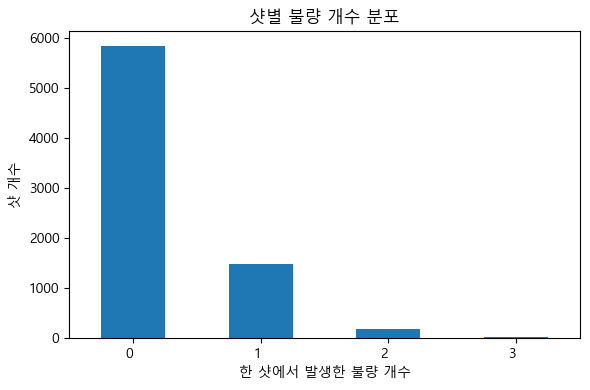

In [17]:
# =========================
# EDA 1) 불량(타겟) 분포 보기
# =========================
# defect_count가 float로 나올 수 있어서 int로 변환
defect_count_int = defect_count.astype(int) 

print("===== [EDA 1] 샷별 불량 개수 분포 =====")
print(defect_count_int.value_counts().sort_index())
print()

plt.figure(figsize=(6,4))
defect_count_int.value_counts().sort_index().plot(kind="bar")
plt.title("샷별 불량 개수 분포")
plt.xlabel("한 샷에서 발생한 불량 개수")
plt.ylabel("샷 개수")
plt.xticks(rotation=0, ha="right")
plt.tight_layout()
plt.show()

===== [EDA 2] 불량 유형 TOP 10 =====
Short_Shot_1     512
Blow_Hole_1      245
Stain_1          209
Short_Shot_2     182
Exfoliation_1    175
Blow_Hole_2      161
Exfoliation_2    134
Deformation_1    109
Bubble_1          72
Deformation_2     65
dtype: int64



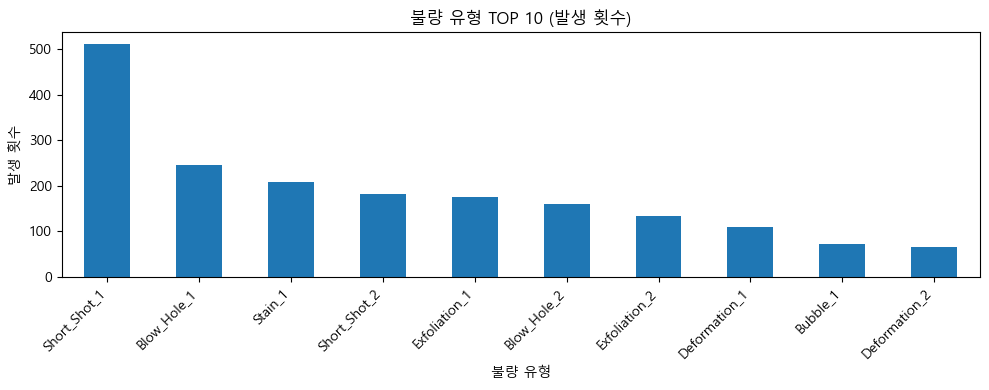

In [ ]:
# =========================
# EDA 2) 불량 유형(Defects) 빈도 TOP 보기
# =========================
defect_freq = defects_df.sum().sort_values(ascending=False)

print("===== [EDA 2] 불량 유형 TOP 10 =====")
print(defect_freq.head(10))
print()

plt.figure(figsize=(10,4))
defect_freq.head(10).plot(kind="bar")
plt.title("불량 유형 TOP 10 (발생 횟수)")
plt.xlabel("불량 유형")
plt.ylabel("발생 횟수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
# =========================
# EDA 3) 공정/센서와 불량의 관계: 상관으로 빠른 스크리닝(가볍게)
# - y가 0/1이면 Pearson corr은 "불량일수록 값이 커지나/작아지나" 감을 준다
# =========================
corr = pd.concat([X, y.rename("y")], axis=1).corr(numeric_only=True)["y"].drop("y")
corr_abs = corr.abs().sort_values(ascending=False)

print("===== [EDA 3] y와 상관 |corr| TOP 10 =====")
print(pd.DataFrame({"corr": corr.loc[corr_abs.index[:10]]}))
print()

===== [EDA 3] y와 상관 |corr| TOP 10 =====
                          corr
Melting_Furnace_Temp -0.145568
Casting_Pressure     -0.145151
Clamping_Force        0.142831
Rapid_Rise_Time       0.132745
Product_Type          0.130745
Spray_1_Time          0.124848
Spray_Time            0.110987
Spray_2_Time          0.106157
Cycle_Time            0.104223
Biscuit_Thickness     0.095882



===== [EDA 4] 불량/양품 평균(mean) =====
   Factory_Temp  Velocity_2  Biscuit_Thickness  Cycle_Time  High_Velocity
y                                                                        
0     32.809237    0.168863          14.140267   27.247725       2.308103
1     32.861575    0.168583          14.895796   29.425933       2.357656

===== [EDA 4] 불량/양품 중앙값(median) =====
   Factory_Temp  Velocity_2  Biscuit_Thickness  Cycle_Time  High_Velocity
y                                                                        
0          32.1       0.168               13.0        22.5          2.157
1          32.1       0.168               16.0        35.0          2.506



<Figure size 1200x400 with 0 Axes>

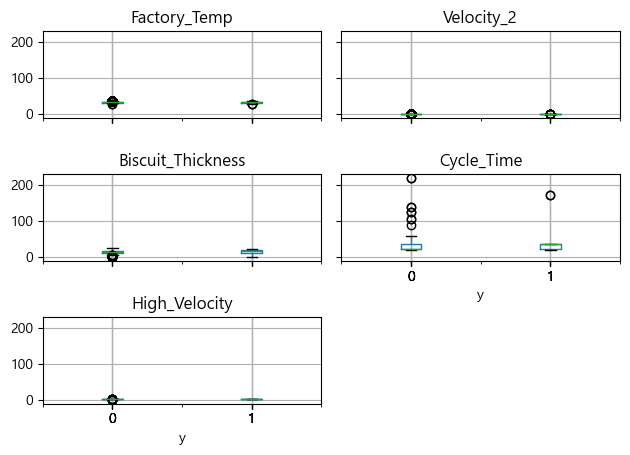

In [20]:
# =========================
# EDA 4) 핵심 변수 5개: 불량/양품 비교(표 + 박스플롯)
# - 이상치에서 많이 튄/의미 있어 보인 변수 중심
# =========================
eda_cols = ["Factory_Temp", "Velocity_2", "Biscuit_Thickness", "Cycle_Time", "High_Velocity"]

tmp = X[eda_cols].copy()
tmp["y"] = y

print("===== [EDA 4] 불량/양품 평균(mean) =====")
print(tmp.groupby("y")[eda_cols].mean())
print()

print("===== [EDA 4] 불량/양품 중앙값(median) =====")
print(tmp.groupby("y")[eda_cols].median())
print()

plt.figure(figsize=(12,4))
tmp.boxplot(column=eda_cols, by="y")
plt.suptitle("")
plt.title("핵심 변수 분포 비교 (양품=0, 불량=1)")
plt.tight_layout()
plt.show()

In [21]:
# =========================
# EDA 5) Product_Type별 불량률 확인(간단)
# =========================
rate_by_pt = pd.crosstab(process_df["Product_Type"], y, normalize="index")

print("===== [EDA 5] Product_Type별 불량률 =====")
print(rate_by_pt)
print()

===== [EDA 5] Product_Type별 불량률 =====
col_0                0         1
Product_Type                    
1             0.824340  0.175660
2             0.714543  0.285457



In [22]:
# =========================
# EDA 6) 불량 유형별 비교(Top3) - 발생/미발생 중앙값 비교
# =========================
top3 = defect_freq.head(3).index.tolist()
d1, d2, d3 = top3[0], top3[1], top3[2]

print("===== [EDA 6] 대표 불량 Top3 =====")
print(top3)
print()

t1 = X[eda_cols].copy(); t1["d"] = defects_df[d1]
t2 = X[eda_cols].copy(); t2["d"] = defects_df[d2]
t3 = X[eda_cols].copy(); t3["d"] = defects_df[d3]

print(f"--- {d1} 발생(1)/미발생(0) 중앙값 ---")
print(t1.groupby("d")[eda_cols].median()); print()

print(f"--- {d2} 발생(1)/미발생(0) 중앙값 ---")
print(t2.groupby("d")[eda_cols].median()); print()

print(f"--- {d3} 발생(1)/미발생(0) 중앙값 ---")
print(t3.groupby("d")[eda_cols].median()); print()

===== [EDA 6] 대표 불량 Top3 =====
['Short_Shot_1', 'Blow_Hole_1', 'Stain_1']

--- Short_Shot_1 발생(1)/미발생(0) 중앙값 ---
   Factory_Temp  Velocity_2  Biscuit_Thickness  Cycle_Time  High_Velocity
d                                                                        
0          32.1       0.168               13.0        22.5          2.159
1          32.0       0.168               17.0        35.9          2.512
2          32.0       0.171               19.0        35.9          2.518

--- Blow_Hole_1 발생(1)/미발생(0) 중앙값 ---
   Factory_Temp  Velocity_2  Biscuit_Thickness  Cycle_Time  High_Velocity
d                                                                        
0          32.1      0.1680               13.0       22.50         2.1590
1          31.9      0.1700               17.0       36.00         2.5210
2          30.9      0.1715               17.0       34.45         2.5205
3          31.6      0.1700               17.0       36.10         2.5150

--- Stain_1 발생(1)/미발생(0) 중앙값 ---
 

# EDA 보고서
1. 목적\
다이캐스팅 공정/센서 데이터에서 불량의 발생 양상과 불량과 관련 있어 보이는 변수를 빠르게 확인

2. 데이터 개요\
전체 데이터: 7,535건\
입력 변수(X): 공정(Process) + 센서(Sensor) 30개 (id 제외)\
타겟(y): 결함(Defects) 26개 중 하나라도 1이면 불량(1), 아니면 양품(0)

3. 불량 발생 분포\
샷별 불량 개수 분포를 확인한 결과\
대부분의 샷은 불량 0개(양품)에 해당\
일부 샷에서 불량 1~3개가 발생했다.\
→ 데이터는 양품 비율이 높게 나타난다. (불균형?)

4. 불량 유형(Defects) 빈도 TOP10\
불량 유형 빈도를 집계한 결과, 가장 많이 발생한 유형은\
Short_Shot_1 (최다)\
Blow_Hole_1\
Stain_1\
이하 Short_Shot_2, Exfoliation_1 등\
불량 유형별 발생 빈도 차이가 크며, 특정 유형에 발생이 집중되는 경향을 보인다.

5. 공정/센서 변수와 불량 관계\
Factory_Temp, Velocity_2, Biscuit_Thickness, Cycle_Time, High_Velocity에 대해\
불량(1) / 양품(0) 분포(박스플롯) 및 평균·중앙값을 비교
Biscuit_Thickness, Cycle_Time, High_Velocity는 불량(1) 집단에서 값이 더 큰 방향성이 관찰되었다. \
Factory_Temp, Velocity_2는 차이가 크지 않거나 제한적으로 보인다. 추가 분석 필요

6. Product_Type별 불량률\
Product_Type별 불량률을 비교한 결과:\
Product_Type 1: 불량률 약 17.6%\
Product_Type 2: 불량률 약 28.5%\
→ 제품 타입에 따라 불량 발생 확률이 차이가 발생, Product_Type이 중요한 설명 변수일 가능성이 있음

7. 결론\
불량은 일부 유형에 집중되어 있으며 데이터는 불균형 구조.\
Cycle_Time, Biscuit_Thickness, High_Velocity 등은 불량과 관련된 후보 변수로 보인다.\
다음 단계로 t-검정(양품 vs 불량) 또는 ANOVA(불량 유형별 비교) 수행


## 통계 검정

### t-test
양품(0) vs 불량(1) 두 집단 평균이 진짜로 다른가?

데이터가 불균형이고 분산이 다를 가능성이 높기 때문에 Welch t-test 시행

In [ ]:
# =========================
# t-test 준비
# =========================
from scipy.stats import ttest_ind
# 검정할 변수(EDA에서 후보로 본 것들)
test_cols = ["Cycle_Time", "Biscuit_Thickness", "High_Velocity", "Factory_Temp", "Velocity_2"]

# 그룹 분리
good = X[y == 0]
bad  = X[y == 1]

print("===== t-test (Welch’s t-test) =====")
print("가설: 두 집단 평균이 같다(H0) vs 다르다(H1)")
print()


# 각 변수별 t-test
for col in test_cols:
    t_stat, p_val = ttest_ind(good[col], bad[col], equal_var=False)
    mean_good = good[col].mean()
    mean_bad  = bad[col].mean()
    med_good  = good[col].median()
    med_bad   = bad[col].median()
    print(f"[{col}]")
    print(f"  mean(양품)= {mean_good:.4f} | mean(불량)= {mean_bad:.4f}")
    print(f"  median(양품)= {med_good:.4f} | median(불량)= {med_bad:.4f}")
    print(f"  t = {t_stat:.4f}, p = {p_val:.6g}")
    print("-" * 50)


print("\n===== 효과크기(Cohen's d) =====")
for col in test_cols:
    x0 = good[col].values
    x1 = bad[col].values

    n0, n1 = len(x0), len(x1)
    s0, s1 = x0.std(ddof=1), x1.std(ddof=1)
    sp = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0+n1-2))
    d = (x1.mean() - x0.mean()) / sp

    print(f"[{col}] d = {d:.3f}")


# ==========================================================
# col = "검정할 변수"
# t, p = ttest_ind(good[col], bad[col], equal_var=False)
# n0, n1 = good[col].shape[0], bad[col].shape[0]
# s0, s1 = good[col].std(ddof=1), bad[col].std(ddof=1)
# sp = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0+n1-2))
# d = (bad[col].mean() - good[col].mean()) / sp

# print(f"[{col}]")
# print(f"  mean(양품)={good[col].mean():.4f} | mean(불량)={bad[col].mean():.4f}")
# print(f"  median(양품)={good[col].median():.4f} | median(불량)={bad[col].median():.4f}")
# print(f"  t={t:.4f}, p={p:.6g}, Cohen's d={d:.3f}")
# print("-"*55)
# ==========================================================

===== t-test (Welch: equal_var=False) =====
가설: 두 집단 평균이 같다(H0) vs 다르다(H1)

[Cycle_Time]
  mean(양품)= 27.2477 | mean(불량)= 29.4259
  median(양품)= 22.5000 | median(불량)= 35.0000
  t = -8.9277, p = 7.91372e-19
--------------------------------------------------
[Biscuit_Thickness]
  mean(양품)= 14.1403 | mean(불량)= 14.8958
  median(양품)= 13.0000 | median(불량)= 16.0000
  t = -8.1399, p = 6.03309e-16
--------------------------------------------------
[High_Velocity]
  mean(양품)= 2.3081 | mean(불량)= 2.3577
  median(양품)= 2.1570 | median(불량)= 2.5060
  t = -8.8073, p = 2.08473e-18
--------------------------------------------------
[Factory_Temp]
  mean(양품)= 32.8092 | mean(불량)= 32.8616
  median(양품)= 32.1000 | median(불량)= 32.1000
  t = -1.0765, p = 0.281818
--------------------------------------------------
[Velocity_2]
  mean(양품)= 0.1689 | mean(불량)= 0.1686
  median(양품)= 0.1680 | median(불량)= 0.1680
  t = 2.7206, p = 0.00654228
--------------------------------------------------

===== 효과크기(Cohen's d) =====
[

|d| < 0.2 : 매우 작음/무시 가능 수준\
0.2 ≤ |d| < 0.5 : 작음\
0.5 ≤ |d| < 0.8 : 중간\
|d| ≥ 0.8 : 큼

In [25]:
alpha = 0.05

# Cycle_Time
t, p = ttest_ind(good["Cycle_Time"], bad["Cycle_Time"], equal_var=False)
print("Cycle_Time:", "유의" if p < alpha else "비유의", "| p =", p)

# Biscuit_Thickness
t, p = ttest_ind(good["Biscuit_Thickness"], bad["Biscuit_Thickness"], equal_var=False)
print("Biscuit_Thickness:", "유의" if p < alpha else "비유의", "| p =", p)

# High_Velocity
t, p = ttest_ind(good["High_Velocity"], bad["High_Velocity"], equal_var=False)
print("High_Velocity:", "유의" if p < alpha else "비유의", "| p =", p)

# Factory_Temp
t, p = ttest_ind(good["Factory_Temp"], bad["Factory_Temp"], equal_var=False)
print("Factory_Temp:", "유의" if p < alpha else "비유의", "| p =", p)

# Velocity_2
t, p = ttest_ind(good["Velocity_2"], bad["Velocity_2"], equal_var=False)
print("Velocity_2:", "유의" if p < alpha else "비유의", "| p =", p)

Cycle_Time: 유의 | p = 7.9137201240722365e-19
Biscuit_Thickness: 유의 | p = 6.033089936425113e-16
High_Velocity: 유의 | p = 2.0847285201329472e-18
Factory_Temp: 비유의 | p = 0.28181802856935
Velocity_2: 유의 | p = 0.006542276791774822


### Welch’s t-test 보고
양품(0)과 불량(1) 두 집단 사이에서 공정/센서 변수의 평균 차이가 통계적으로 유의한지 확인해\
불량과 관련된 후보 변수를 선별한다.

1. 데이터 및 검정 설정\
비교 집단: 양품(y=0) vs 불량(y=1)\
검정 방법: Welch’s t-test (equal_var=False, 등분산 가정 X)\
유의수준: α = 0.05\
검정 변수: Cycle_Time, Biscuit_Thickness, High_Velocity, Factory_Temp, Velocity_2\
효과크기: Cohen’s d

2. 검정 결과 요약
    - Cycle_Time\
    평균(양품)=27.25, 평균(불량)=29.43\
    유의하나 효과크기는 작음\
    불량 집단에서 Cycle_Time이 더 큰 경향이 있으며, 통계적으로 유의한 차이가 확인됨.

    - Biscuit_Thickness\
    평균(양품)=14.14, 평균(불량)=14.90
    유의하나 효과크기는 작음\
    불량 집단에서 Biscuit_Thickness가 더 큰 경향이 있으며, 유의한 차이가 확인됨.

    - High_Velocity\
    평균(양품)=2.308, 평균(불량)=2.358\
    유의하나 효과크기는 작음\
    불량 집단에서 High_Velocity가 더 큰 경향이 있으며, 유의한 차이가 확인됨.

    - Velocity_2\
        평균(양품)=0.1689, 평균(불량)=0.1686\
    유의하나 효과크기는 매우 작음\
    p값은 유의하지만 평균 차이는 매우 작고(중앙값도 동일), 영향이 크지 않을 가능성이 있다.

    - Factory_Temp: 유의한 차이가 없던 변수\
    평균(양품)=32.81, 평균(불량)=32.86
    유의하지 않나 효과 크기 거의 없음\
    품/불량 간 평균 차이를 근거로 보기 어렵다.

3. 결론\
Welch t-test 기준, Cycle_Time / Biscuit_Thickness / High_Velocity는 양품과 불량 집단 사이에서 통계적으로 유의한 평균 차이가 확인되어 불량 관련 후보 변수로 볼 수 있다.\
다만 효과크기 모두 0.22~0.25 수준으로 차이가 그리 크지 않음을 유의하고 해석해야 한다.\



### ANOVA
불량 유형(여러 그룹) 사이에서 어떤 공정 변수 평균이 다른가?

In [29]:
import numpy as np
from scipy.stats import f_oneway

# 1) Top3 불량 유형 선정
top3 = defect_freq.head(3).index.tolist()
d1, d2, d3 = top3[0], top3[1], top3[2]
print("ANOVA 대상 불량 Top3:", top3)

# 2) 단일 결함 샷만 선택
mask_single = (defect_count.astype(int) == 1)

g1_mask = mask_single & (defects_df[d1] == 1)
g2_mask = mask_single & (defects_df[d2] == 1)
g3_mask = mask_single & (defects_df[d3] == 1)

print("\n각 그룹 샘플 수(단일 결함 샷):")
print(d1, g1_mask.sum())
print(d2, g2_mask.sum())
print(d3, g3_mask.sum())

# 3) 비교할 변수 1개 (일단 Cycle_Time만)
g1 = X.loc[g1_mask, "Cycle_Time"]
g2 = X.loc[g2_mask, "Cycle_Time"]
g3 = X.loc[g3_mask, "Cycle_Time"]

# 4) ANOVA
F, p = f_oneway(g1, g2, g3)

print("\n===== One-way ANOVA 결과 (변수: Cycle_Time) =====")
print("F =", F)
print("p =", p)

ANOVA 대상 불량 Top3: ['Short_Shot_1', 'Blow_Hole_1', 'Stain_1']

각 그룹 샘플 수(단일 결함 샷):
Short_Shot_1 411
Blow_Hole_1 172
Stain_1 127

===== One-way ANOVA 결과 (변수: Cycle_Time) =====
F = 64.58508500235642
p = 1.7321952798990702e-26
